# CVE Growth Report v2 — Modern Social Media Infographics
Generates polished, social-media-optimized CVE growth infographics in multiple formats:
- **Square (1:1)** — LinkedIn / Instagram
- **Landscape (16:9)** — Twitter/X / Open Graph
- **Animated GIF** — Cumulative line drawing itself over time
- **Dark & Light themes** with modern typography, gradient fills, and lollipop charts

In [1]:
# ── Cell 1: Imports & Data Loading ──────────────────────────────────────────────
import glob, json, logging, os, warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
try:
    import pyarrow  # optional: faster string ops in Pandas 3
except ImportError:
    pass
from datetime import datetime
from matplotlib.patches import FancyBboxPatch
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
import io

logging.getLogger('matplotlib.font_manager').disabled = True
warnings.filterwarnings("ignore")

# ── Load NVD data ───────────────────────────────────────────────────────────────
data_path = '../data/nvd.jsonl'
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Data file not found at {data_path}")

def get_nested_value(entry, keys, default='Missing_Data'):
    try:
        for key in keys:
            entry = entry[key]
        return entry
    except (KeyError, IndexError):
        return default

row_accumulator = []
with open(data_path, 'r', encoding='utf-8') as f:
    nvd_data = json.load(f)
    for entry in nvd_data:
        new_row = {
            'CVE': get_nested_value(entry, ['cve', 'id']),
            'Published': get_nested_value(entry, ['cve', 'published']),
            'BaseScore': get_nested_value(entry, ['cve', 'metrics', 'cvssMetricV31', 0, 'cvssData', 'baseScore'], '0.0'),
            'Status': get_nested_value(entry, ['cve', 'vulnStatus'], '')
        }
        row_accumulator.append(new_row)

nvd = pd.DataFrame(row_accumulator)
nvd = nvd[~nvd.Status.str.contains('Rejected')]
nvd['Published'] = pd.to_datetime(nvd['Published'])
nvd['BaseScore'] = pd.to_numeric(nvd['BaseScore'], errors='coerce').replace(0, np.nan)
print(f"Loaded {len(nvd):,} CVEs")

Loaded 317,861 CVEs


In [2]:
# ── Cell 2: Date Filtering ─────────────────────────────────────────────────────
today = datetime.now()
last_complete_month = today.month - 1 if today.month > 1 else 12

print(f"Today: {today.strftime('%Y-%m-%d')}")
print(f"Last complete month: {last_complete_month}")

Year_2026 = ((nvd['Published'].dt.year == 2026) &
             (nvd['Published'].dt.month <= last_complete_month))
Year_2025 = ((nvd['Published'].dt.year == 2025) &
             (nvd['Published'].dt.month <= last_complete_month))
current_year_data = nvd[Year_2026]
previous_year_data = nvd[Year_2025]

print(f"2026 CVEs (through month {last_complete_month}): {len(current_year_data):,}")
print(f"2025 CVEs (through month {last_complete_month}): {len(previous_year_data):,}")

Today: 2026-03-01
Last complete month: 2
2026 CVEs (through month 2): 8,932
2025 CVEs (through month 2): 7,950


In [3]:
# ── Cell 3: Metrics Calculation ─────────────────────────────────────────────────
current_year, previous_year = 2026, 2025

def get_cumulative_by_doy(data, year):
    daily_counts = data.groupby(data['Published'].dt.dayofyear).size()
    all_days = pd.Series(range(1, 367))
    daily_counts = daily_counts.reindex(all_days, fill_value=0)
    cumulative = daily_counts.cumsum()
    dates = pd.date_range(start=f'{year}-01-01', periods=366)
    return dates, cumulative

current_dates, current_cumulative = get_cumulative_by_doy(current_year_data, current_year)
previous_dates, previous_cumulative = get_cumulative_by_doy(previous_year_data, previous_year)

normalized_previous_dates = [d.replace(year=current_year) for d in previous_dates
                             if not (d.month == 2 and d.day == 29)]
if len(normalized_previous_dates) < len(previous_cumulative):
    normalized_previous_dates.append(pd.Timestamp(f'{current_year}-12-31'))

if not current_year_data.empty:
    last_doy = current_year_data['Published'].dt.dayofyear.max()
    current_cumulative = current_cumulative.iloc[:last_doy]
    current_dates = current_dates[:last_doy]
    previous_cumulative = previous_cumulative.iloc[:last_doy]
    normalized_previous_dates = normalized_previous_dates[:last_doy]

# Key metrics
graph_total_cves_2026 = int(current_cumulative.iloc[-1])
graph_total_cves_2025 = int(previous_cumulative.iloc[-1])
graph_yoy_growth = ((graph_total_cves_2026 - graph_total_cves_2025) / graph_total_cves_2025) * 100

current_month_name = current_dates[-1].strftime('%B')
current_month_num  = current_dates[-1].month
report_date        = current_dates[-1].strftime('%B %d, %Y')

months_short  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
months_to_show = current_month_num

def get_monthly_counts_by_year(nvd_df, start_year, end_year):
    monthly_data = {}
    for year in range(start_year, end_year + 1):
        year_data = nvd_df[nvd_df['Published'].dt.year == year]
        monthly_counts = year_data.groupby(year_data['Published'].dt.month).size()
        monthly_data[year] = monthly_counts.reindex(range(1, 13), fill_value=0)
    return pd.DataFrame(monthly_data)

monthly_df   = get_monthly_counts_by_year(nvd, 2018, 2026)
monthly_df.index = months_short
monthly_2026 = monthly_df[2026].values

yoy_by_month = []
for i in range(months_to_show):
    if monthly_df[2025].iloc[i] > 0:
        yoy = ((monthly_df[2026].iloc[i] - monthly_df[2025].iloc[i]) / monthly_df[2025].iloc[i]) * 100
    else:
        yoy = 0
    yoy_by_month.append(yoy)

specific_month_data = monthly_df.iloc[current_month_num - 1]
yoy_change_month = ((specific_month_data[2026] - specific_month_data[2025]) /
                     specific_month_data[2025] * 100) if specific_month_data[2025] > 0 else 0

daily_2026 = current_year_data.groupby(current_year_data['Published'].dt.date).size()
daily_2026.index = pd.to_datetime(daily_2026.index)
overall_avg = daily_2026.mean()

best_month_2026  = months_short[monthly_2026[:months_to_show].argmax()]
best_month_count = monthly_2026[:months_to_show].max()
worst_month_2026  = months_short[monthly_2026[:months_to_show].argmin()]
worst_month_count = monthly_2026[:months_to_show].min()

max_yoy_idx   = np.argmax(yoy_by_month)
max_yoy_month = months_short[max_yoy_idx]
max_yoy_value = yoy_by_month[max_yoy_idx]

# Monthly sparkline data (last 6 months for mini-chart in KPI card)
spark_months = min(months_to_show, 6)
spark_data_2026 = monthly_df[2026].values[max(0, months_to_show - spark_months):months_to_show]
spark_data_2025 = monthly_df[2025].values[max(0, months_to_show - spark_months):months_to_show]

# ── Previous month's metrics (for bounce-back / momentum narrative) ─────────
if months_to_show >= 2:
    prev_month_idx = current_month_num - 2  # 0-indexed
    prev_month_name_short = months_short[prev_month_idx]
    prev_month_yoy = yoy_by_month[prev_month_idx]
    # Previous month's cumulative YTD growth
    prev_ytd_2026 = int(monthly_df[2026].values[:current_month_num - 1].sum())
    prev_ytd_2025 = int(monthly_df[2025].values[:current_month_num - 1].sum())
    prev_ytd_growth = ((prev_ytd_2026 - prev_ytd_2025) / prev_ytd_2025 * 100) if prev_ytd_2025 > 0 else 0
    # Full month name
    import calendar
    prev_month_full = calendar.month_name[current_month_num - 1]
else:
    prev_month_name_short = None
    prev_month_yoy = None
    prev_ytd_growth = None
    prev_month_full = None

print(f"Report Date: {report_date}")
print(f"Total CVEs 2026: {graph_total_cves_2026:,}  |  2025: {graph_total_cves_2025:,}")
print(f"YoY Growth: {graph_yoy_growth:+.1f}%  |  Daily Avg: {overall_avg:.0f}")
if prev_month_yoy is not None:
    print(f"Previous month ({prev_month_full}): {prev_month_yoy:+.1f}% YoY  |  YTD after {prev_month_full}: {prev_ytd_growth:+.1f}%")

Report Date: February 28, 2026
Total CVEs 2026: 8,932  |  2025: 7,950
YoY Growth: +12.4%  |  Daily Avg: 151
Previous month (January): +0.9% YoY  |  YTD after January: +0.9%


In [4]:
# ── Cell 4: Font & Theme Setup ─────────────────────────────────────────────────
# Use Avenir Next (macOS) with fallback to Helvetica Neue → sans-serif
FONT_CANDIDATES = ['Avenir Next', 'Helvetica Neue', 'Arial']
FONT_FAMILY = 'sans-serif'
for candidate in FONT_CANDIDATES:
    if any(candidate.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        FONT_FAMILY = candidate
        break

plt.rcParams.update({
    'font.family': FONT_FAMILY,
    'font.weight': 'normal',
    'axes.unicode_minus': False,
})
print(f"Using font: {FONT_FAMILY}")

# ── Theme definitions ──────────────────────────────────────────────────────────
THEMES = {
    'dark': dict(
        bg          = '#0d1117',
        bg_grad     = '#161b22',
        card        = '#161b22',
        card_border = '#30363d',
        accent      = '#58a6ff',        # GitHub-blue accent
        accent2     = '#bc8cff',        # Purple secondary
        text        = '#f0f6fc',
        muted       = '#8b949e',
        grid        = '#21262d',
        positive    = '#3fb950',
        negative    = '#f85149',
        line_curr   = '#58a6ff',
        line_prev   = '#484f58',
        bar_curr    = '#58a6ff',
        bar_prev    = '#30363d',
        gradient_top= '#58a6ff',
        gradient_bot= '#0d1117',
        shadow      = '#010409',
    ),
    'light': dict(
        bg          = '#ffffff',
        bg_grad     = '#f6f8fa',
        card        = '#f6f8fa',
        card_border = '#d0d7de',
        accent      = '#0969da',
        accent2     = '#8250df',
        text        = '#1f2328',
        muted       = '#656d76',
        grid        = '#d8dee4',
        positive    = '#1a7f37',
        negative    = '#cf222e',
        line_curr   = '#0969da',
        line_prev   = '#afb8c1',
        bar_curr    = '#0969da',
        bar_prev    = '#d0d7de',
        gradient_top= '#0969da',
        gradient_bot= '#ffffff',
        shadow      = '#b1bac4',
    ),
}
print("Themes configured ✓")

Using font: Avenir Next
Themes configured ✓


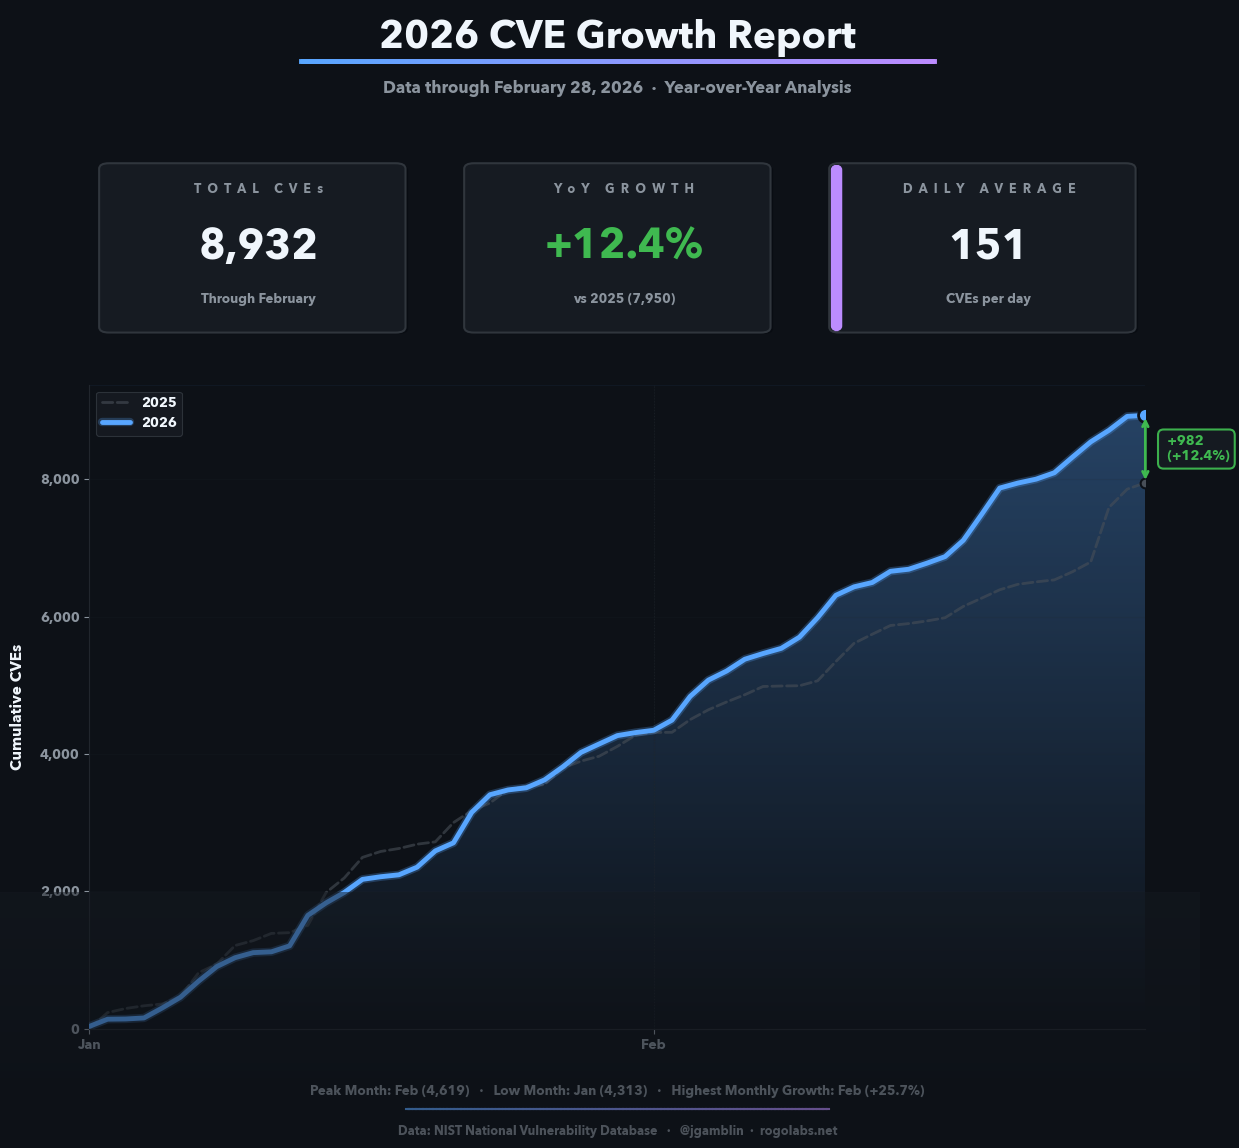


──────────────────────────────────────────────────
Generated 4 files:
  ✓ images/CVE_Growth_2026_dark_square.png  (407 KB)
  ✓ images/CVE_Growth_2026_dark_landscape.png  (402 KB)
  ✓ images/CVE_Growth_2026_light_square.png  (417 KB)
  ✓ images/CVE_Growth_2026_light_landscape.png  (413 KB)


In [5]:
# ── Cell 5: Modern Infographic Generator ────────────────────────────────────────

def _gradient_fill(ax, x, y, color_top, color_bot, alpha=0.45):
    """Gradient fill under a line using imshow mapped to data coords."""
    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list('grad', [color_bot, color_top])
    z = np.linspace(0, 1, 256).reshape(-1, 1)
    xmin, xmax = mdates.date2num(x[0]), mdates.date2num(x[-1])
    ymin, ymax = 0, float(np.max(y)) * 1.05
    ax.imshow(z, aspect='auto', cmap=cmap, origin='lower',
              extent=[xmin, xmax, ymin, ymax], alpha=alpha, zorder=0)
    # Mask above the line
    ax.fill_between(x, y, ymax, color=ax.get_facecolor(), zorder=1, linewidth=0)

def _draw_card(ax, t, x, y, w, h, fc, ec, shadow_color, theme):
    """Draw a rounded card with drop shadow."""
    shadow_off = 0.008
    shadow = FancyBboxPatch((x + shadow_off, y - shadow_off), w, h,
                            boxstyle="round,pad=0.01,rounding_size=0.03",
                            facecolor=shadow_color, edgecolor='none',
                            alpha=0.35, transform=t, zorder=0)
    ax.add_patch(shadow)
    card = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.01,rounding_size=0.03",
                          facecolor=fc, edgecolor=ec, linewidth=1.5,
                          transform=t, zorder=1)
    ax.add_patch(card)
    return card

def _draw_sparkline(ax, data, color, x_start, x_end, y_start, y_end):
    """Draw a tiny sparkline within axis-fraction coordinates."""
    if len(data) < 2:
        return
    n = len(data)
    xs = np.linspace(x_start, x_end, n)
    dmin, dmax = np.min(data), np.max(data)
    if dmax == dmin:
        dmax = dmin + 1
    ys = y_start + (data - dmin) / (dmax - dmin) * (y_end - y_start)
    ax.plot(xs, ys, color=color, linewidth=1.8, solid_capstyle='round',
            transform=ax.transAxes, zorder=5, alpha=0.8)
    ax.plot(xs[-1], ys[-1], 'o', color=color, markersize=4,
            transform=ax.transAxes, zorder=6)


def create_infographic_v2(theme_name='dark', aspect='square'):
    """
    Generate a modern infographic.
    aspect: 'square' (12×12, best for LinkedIn/Instagram)
            'landscape' (16×9, best for Twitter/Open Graph)
    """
    T = THEMES[theme_name]

    if aspect == 'square':
        fig = plt.figure(figsize=(12, 12))
    else:
        fig = plt.figure(figsize=(16, 9))

    fig.patch.set_facecolor(T['bg'])

    # ── Subtle background gradient (bottom→top, dark→slightly lighter) ──────
    bg_grad = np.linspace(0, 1, 256).reshape(-1, 1)
    bg_cmap = LinearSegmentedColormap.from_list('bg', [T['bg'], T['bg_grad']])
    fig.figimage(np.tile(bg_grad, (1, int(fig.get_figwidth() * fig.dpi))),
                 cmap=bg_cmap, alpha=0.5, origin='lower',
                 resize=False)

    # ── Layout ──────────────────────────────────────────────────────────────
    if aspect == 'square':
        gs = fig.add_gridspec(4, 3,
            height_ratios=[0.55, 1.0, 3.5, 0.35],
            hspace=0.18, wspace=0.12,
            left=0.06, right=0.94, top=0.96, bottom=0.02)
    else:  # landscape
        gs = fig.add_gridspec(4, 3,
            height_ratios=[0.45, 0.85, 3.5, 0.3],
            hspace=0.2, wspace=0.12,
            left=0.05, right=0.95, top=0.96, bottom=0.02)
    footer_row = 3

    # ════════════════════════════════════════════════════════════════════════
    # HEADER
    # ════════════════════════════════════════════════════════════════════════
    ax_h = fig.add_subplot(gs[0, :])
    ax_h.set_facecolor('none')
    ax_h.axis('off')

    # Title
    title_size = 28 if aspect == 'square' else 26
    ax_h.text(0.5, 0.72, f'{current_year} CVE Growth Report',
              fontsize=title_size, fontweight='bold', color=T['text'],
              ha='center', va='center', transform=ax_h.transAxes,
              fontfamily=FONT_FAMILY)
    ax_h.text(0.5, 0.22, f'Data through {report_date}  ·  Year-over-Year Analysis',
              fontsize=12, color=T['muted'], ha='center', va='center',
              transform=ax_h.transAxes, fontstyle='italic')

    # Gradient accent line under header
    n_grad = 300
    for i in range(n_grad):
        frac = i / n_grad
        r1, g1, b1 = int(T['accent'][1:3],16)/255, int(T['accent'][3:5],16)/255, int(T['accent'][5:7],16)/255
        r2, g2, b2 = int(T['accent2'][1:3],16)/255, int(T['accent2'][3:5],16)/255, int(T['accent2'][5:7],16)/255
        c = (r1+(r2-r1)*frac, g1+(g2-g1)*frac, b1+(b2-b1)*frac)
        ax_h.axhline(y=-0.05, xmin=0.2 + 0.6*frac/1,
                     xmax=0.2 + 0.6*(frac + 1/n_grad),
                     color=c, linewidth=3.5)

    # ════════════════════════════════════════════════════════════════════════
    # KPI CARDS
    # ════════════════════════════════════════════════════════════════════════
    arrow_up   = '+'
    arrow_down = '-'

    metrics = [
        {
            'title': 'TOTAL CVEs',
            'value': f'{graph_total_cves_2026:,}',
            'sub':   f'Through {current_month_name}',
            'color': None,
            'accent_bar': None,
            'sparkline': None,
            'spark_color': None,
        },
        {
            'title': 'YoY GROWTH',
            'value': f'{graph_yoy_growth:+.1f}%',
            'sub':   f'vs {previous_year} ({graph_total_cves_2025:,})',
            'color': T['positive'] if graph_yoy_growth >= 0 else T['negative'],
            'accent_bar': None,
            'sparkline': None,
            'spark_color': None,
        },
        {
            'title': 'DAILY AVERAGE',
            'value': f'{overall_avg:.0f}',
            'sub':   'CVEs per day',
            'color': None,
            'accent_bar': T['accent2'],
            'sparkline': None,
            'spark_color': T['accent2'],
        },
    ]

    for idx, m in enumerate(metrics):
        ax = fig.add_subplot(gs[1, idx])
        ax.set_facecolor('none')
        ax.axis('off')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)

        # Card with shadow
        _draw_card(ax, ax.transAxes, 0.04, 0.05, 0.92, 0.90,
                   T['card'], T['card_border'], T['shadow'], theme_name)

        # Left accent bar (only if specified)
        if m['accent_bar'] is not None:
            accent_bar = FancyBboxPatch((0.04, 0.05), 0.025, 0.90,
                                         boxstyle="round,pad=0.005,rounding_size=0.03",
                                         facecolor=m['accent_bar'], edgecolor='none',
                                         transform=ax.transAxes, zorder=3)
            ax.add_patch(accent_bar)

        # Title (uppercase, letter-spaced via spaces)
        title_text = '  '.join(m['title'])
        ax.text(0.52, 0.82, title_text, fontsize=9, color=T['muted'],
                ha='center', va='center', transform=ax.transAxes,
                fontweight='bold', fontfamily=FONT_FAMILY)

        # Value
        val_color = m['color'] if m['color'] else T['text']
        val_size = 30 if len(m['value']) < 8 else 26
        ax.text(0.52, 0.50, m['value'], fontsize=val_size, color=val_color,
                ha='center', va='center', transform=ax.transAxes,
                fontweight='bold', fontfamily=FONT_FAMILY)

        # Subtitle
        ax.text(0.52, 0.22, m['sub'], fontsize=9.5, color=T['muted'],
                ha='center', va='center', transform=ax.transAxes)

        # Mini sparkline (bottom-right of card)
        if m['sparkline'] is not None and len(m['sparkline']) >= 2:
            _draw_sparkline(ax, m['sparkline'].astype(float), m['spark_color'],
                            0.68, 0.92, 0.12, 0.35)

    # ════════════════════════════════════════════════════════════════════════
    # MAIN CUMULATIVE CHART with gradient fill
    # ════════════════════════════════════════════════════════════════════════
    ax_main = fig.add_subplot(gs[2, :])
    ax_main.set_facecolor(T['bg'])

    # Gradient fill under 2026 line
    _gradient_fill(ax_main, current_dates, current_cumulative,
                   T['gradient_top'], T['gradient_bot'], alpha=0.35)

    # Month boundary markers
    for m_num in range(1, current_month_num + 1):
        try:
            boundary = pd.Timestamp(f'{current_year}-{m_num:02d}-01')
            if boundary >= current_dates[0] and boundary <= current_dates[-1]:
                ax_main.axvline(boundary, color=T['grid'], linewidth=0.8,
                                linestyle=':', alpha=0.5, zorder=2)
        except:
            pass

    # 2025 line (subtle)
    ax_main.plot(normalized_previous_dates, previous_cumulative,
                 linewidth=2, color=T['line_prev'], linestyle='--',
                 label=f'{previous_year}', alpha=0.6, zorder=3,
                 dash_capstyle='round')

    # 2026 line (bold, with glow)
    ax_main.plot(current_dates, current_cumulative, linewidth=3.5,
                 color=T['line_curr'], label=f'{current_year}', zorder=4,
                 solid_capstyle='round',
                 path_effects=[pe.withStroke(linewidth=6, foreground=T['line_curr'], alpha=0.25)])

    # End-point dots
    ax_main.plot(current_dates[-1], current_cumulative.iloc[-1], 'o',
                 color=T['line_curr'], markersize=10, zorder=6,
                 markeredgecolor=T['bg'], markeredgewidth=2)
    ax_main.plot(normalized_previous_dates[-1], previous_cumulative.iloc[-1],
                 'o', color=T['line_prev'], markersize=7, zorder=6,
                 markeredgecolor=T['bg'], markeredgewidth=1.5)

    # Gap annotation with double arrow
    growth_diff = graph_total_cves_2026 - graph_total_cves_2025
    sign = '+' if growth_diff >= 0 else ''
    ann_color = T['positive'] if graph_yoy_growth >= 0 else T['negative']

    mid_y = (current_cumulative.iloc[-1] + previous_cumulative.iloc[-1]) / 2
    ax_main.annotate('', xy=(current_dates[-1], current_cumulative.iloc[-1]),
                     xytext=(current_dates[-1], previous_cumulative.iloc[-1]),
                     arrowprops=dict(arrowstyle='<->', color=ann_color, lw=2),
                     zorder=7)
    ax_main.text(current_dates[-1] + pd.Timedelta(days=1), mid_y,
                 f' {sign}{growth_diff:,}\n ({graph_yoy_growth:+.1f}%)',
                 fontsize=10, fontweight='bold', color=ann_color,
                 va='center', ha='left',
                 bbox=dict(boxstyle='round,pad=0.4', facecolor=T['card'],
                           edgecolor=ann_color, linewidth=1.5, alpha=0.95),
                 zorder=8)

    ax_main.set_ylabel('Cumulative CVEs', fontsize=11, color=T['text'],
                       fontweight='bold', labelpad=10)
    ax_main.tick_params(colors=T['muted'], labelsize=10)
    ax_main.xaxis.set_major_locator(mdates.MonthLocator())
    ax_main.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax_main.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax_main.grid(True, alpha=0.15, color=T['grid'], linewidth=0.8)
    for spine in ['top', 'right']:
        ax_main.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax_main.spines[spine].set_color(T['grid'])
        ax_main.spines[spine].set_linewidth(0.8)

    legend = ax_main.legend(loc='upper left', fontsize=10, frameon=True,
                            facecolor=T['card'], edgecolor=T['card_border'],
                            labelcolor=T['text'], framealpha=0.9)
    legend.get_frame().set_linewidth(0.8)

    # ════════════════════════════════════════════════════════════════════════
    # FOOTER
    # ════════════════════════════════════════════════════════════════════════
    ax_f = fig.add_subplot(gs[footer_row, :])
    ax_f.set_facecolor('none')
    ax_f.axis('off')

    if months_to_show >= 2:
        insights = (f"Peak Month: {best_month_2026} ({int(best_month_count):,})   ·   "
                    f"Low Month: {worst_month_2026} ({int(worst_month_count):,})   ·   "
                    f"Highest Monthly Growth: {max_yoy_month} ({max_yoy_value:+.1f}%)")
        ax_f.text(0.5, 0.72, insights, fontsize=9.5, color=T['muted'],
                  ha='center', va='center', transform=ax_f.transAxes)

    # Gradient divider before attribution
    for i in range(n_grad):
        frac = i / n_grad
        r1, g1, b1 = int(T['accent'][1:3],16)/255, int(T['accent'][3:5],16)/255, int(T['accent'][5:7],16)/255
        r2, g2, b2 = int(T['accent2'][1:3],16)/255, int(T['accent2'][3:5],16)/255, int(T['accent2'][5:7],16)/255
        c = (r1+(r2-r1)*frac, g1+(g2-g1)*frac, b1+(b2-b1)*frac)
        ax_f.axhline(y=0.45, xmin=0.3 + 0.4*frac,
                     xmax=0.3 + 0.4*(frac + 1/n_grad),
                     color=c, linewidth=1.5)

    ax_f.text(0.5, 0.10,
              'Data: NIST National Vulnerability Database   ·   @jgamblin  ·  rogolabs.net',
              fontsize=9, color=T['muted'], ha='center', va='center',
              transform=ax_f.transAxes, fontstyle='italic')

    return fig


# ════════════════════════════════════════════════════════════════════════════════
# Generate all variants
# ════════════════════════════════════════════════════════════════════════════════
img_dir = 'images'
os.makedirs(img_dir, exist_ok=True)
output_files = []

for theme in ['dark', 'light']:
    for aspect in ['square', 'landscape']:
        fig = create_infographic_v2(theme, aspect)
        fname_base = f'{img_dir}/CVE_Growth_{current_year}_{theme}_{aspect}'

        # PNG (300 DPI)
        png_path = f'{fname_base}.png'
        fig.savefig(png_path, dpi=300, bbox_inches='tight',
                    facecolor=fig.get_facecolor(), pad_inches=0.3)
        output_files.append(png_path)
        if aspect == 'square' and theme == 'dark':
            plt.show()  # Preview the primary variant

        plt.close(fig)

print(f"\n{'─'*50}")
print(f"Generated {len(output_files)} files:")
for f in output_files:
    size_kb = os.path.getsize(f) / 1024
    print(f"  ✓ {f}  ({size_kb:,.0f} KB)")

In [6]:
# ── Cell 6: Animated GIF — Cumulative Line Drawing Itself ───────────────────────
from matplotlib.animation import FuncAnimation, PillowWriter

def create_animated_gif(theme_name='dark', max_frames=60):
    """
    Create an animated GIF showing the 2026 cumulative line drawing itself
    day-by-day alongside the static 2025 comparison line.
    Loops once, shows YoY growth %, and includes attribution.
    """
    T = THEMES[theme_name]
    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor(T['bg'])
    ax.set_facecolor(T['bg'])

    # Static 2025 line
    ax.plot(normalized_previous_dates, previous_cumulative,
            linewidth=2, color=T['line_prev'], linestyle='--',
            alpha=0.5, label=f'{previous_year}', dash_capstyle='round')

    # Setup axes
    ax.set_xlim(current_dates[0], current_dates[-1] + pd.Timedelta(days=2))
    y_max = max(current_cumulative.max(), previous_cumulative.max()) * 1.15
    ax.set_ylim(0, y_max)
    ax.set_ylabel('Cumulative CVEs', fontsize=12, color=T['text'], fontweight='bold')
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(colors=T['muted'], labelsize=10)
    ax.grid(True, alpha=0.12, color=T['grid'])
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_color(T['grid'])

    # Title (no emoji)
    ax.set_title(f'{current_year} CVE Growth Report',
                 fontsize=20, fontweight='bold', color=T['text'],
                 pad=15, fontfamily=FONT_FAMILY)

    # Attribution (bottom-left)
    fig.text(0.13, 0.02, '@jgamblin / rogolabs.net',
             fontsize=9, color=T['muted'], fontstyle='italic',
             fontfamily=FONT_FAMILY, ha='left', va='bottom')

    legend = ax.legend(loc='upper left', fontsize=10, frameon=True,
                       facecolor=T['card'], edgecolor=T['card_border'],
                       labelcolor=T['text'])

    # Animated line + dot
    line_anim, = ax.plot([], [], linewidth=3, color=T['line_curr'],
                         solid_capstyle='round', label=f'{current_year}',
                         path_effects=[pe.withStroke(linewidth=5.5,
                                       foreground=T['line_curr'], alpha=0.2)])
    dot_anim, = ax.plot([], [], 'o', color=T['line_curr'], markersize=8,
                        markeredgecolor=T['bg'], markeredgewidth=2)
    count_text = ax.text(0.98, 0.02, '', transform=ax.transAxes,
                         fontsize=16, fontweight='bold', color=T['accent'],
                         ha='right', va='bottom', fontfamily=FONT_FAMILY)

    # YoY growth label (hidden until final frame)
    yoy_color = T['positive'] if graph_yoy_growth >= 0 else T['negative']
    yoy_text = ax.text(0.98, 0.10, '', transform=ax.transAxes,
                       fontsize=14, fontweight='bold', color=yoy_color,
                       ha='right', va='bottom', fontfamily=FONT_FAMILY)

    # Subsample frames for manageable GIF size
    total_pts = len(current_dates)
    step = max(1, total_pts // max_frames)
    frame_indices = list(range(0, total_pts, step))
    if frame_indices[-1] != total_pts - 1:
        frame_indices.append(total_pts - 1)

    # Add extra hold frames at the end so the final state is visible
    hold_frames = 15
    last_idx = frame_indices[-1]
    frame_indices.extend([last_idx] * hold_frames)

    def animate(frame_idx):
        i = frame_indices[frame_idx]
        line_anim.set_data(current_dates[:i+1], current_cumulative.iloc[:i+1])
        dot_anim.set_data([current_dates[i]], [current_cumulative.iloc[i]])
        count_text.set_text(f'{int(current_cumulative.iloc[i]):,} CVEs')

        # Show YoY % on the last real frame onward
        if i == last_idx:
            yoy_text.set_text(f'{graph_yoy_growth:+.1f}% YoY')
        else:
            yoy_text.set_text('')

        return line_anim, dot_anim, count_text, yoy_text

    anim = FuncAnimation(fig, animate, frames=len(frame_indices),
                         interval=80, blit=True, repeat=False)

    gif_path = f'{img_dir}/CVE_Growth_{current_year}_{theme_name}_animated.gif'
    # Use PillowWriter to control loop count (loop=1 means play once then stop)
    writer = PillowWriter(fps=12)
    anim.save(gif_path, writer=writer, dpi=150,
              savefig_kwargs={'facecolor': T['bg']})
    plt.close(fig)

    # Post-process with Pillow to set loop=1 (play once)
    img = Image.open(gif_path)
    frames = []
    try:
        while True:
            frames.append(img.copy())
            img.seek(img.tell() + 1)
    except EOFError:
        pass
    # Save with loop=1 (0=infinite, 1=play twice... GIF spec: loop=number of *extra* loops)
    # To truly play once: don't include the loop extension, but most viewers need loop=1
    frames[0].save(gif_path, save_all=True, append_images=frames[1:],
                   duration=80, loop=1)

    size_mb = os.path.getsize(gif_path) / (1024 * 1024)
    print(f"  ✓ {gif_path}  ({size_mb:.1f} MB)")
    return gif_path

# Generate dark + light animated GIFs
gif_dark  = create_animated_gif('dark',  max_frames=60)
gif_light = create_animated_gif('light', max_frames=60)

  ✓ images/CVE_Growth_2026_dark_animated.gif  (0.8 MB)
  ✓ images/CVE_Growth_2026_light_animated.gif  (0.7 MB)


In [7]:
# ── Cell 7: Social Media Post Templates ─────────────────────────────────────────

# ── Build bounce-back / momentum narrative ──────────────────────────────────────
if prev_month_yoy is not None and months_to_show >= 2:
    # Determine the narrative framing based on month-over-month momentum shift
    momentum_delta = abs(yoy_change_month) - abs(prev_month_yoy)
    if yoy_change_month > prev_month_yoy + 5:
        # Significant acceleration from previous month
        bounce_line = (
            f"After near-flat growth in {prev_month_full} ({prev_month_yoy:+.1f}% YoY), "
            f"{current_month_name} surged to {yoy_change_month:+.1f}% — "
            f"pushing YTD growth from {prev_ytd_growth:+.1f}% to {graph_yoy_growth:+.1f}%."
        )
    elif yoy_change_month < prev_month_yoy - 5:
        # Deceleration
        bounce_line = (
            f"Growth cooled in {current_month_name} ({yoy_change_month:+.1f}% YoY) "
            f"after {prev_month_full}'s {prev_month_yoy:+.1f}%, "
            f"bringing YTD growth to {graph_yoy_growth:+.1f}%."
        )
    else:
        # Roughly steady
        bounce_line = (
            f"Growth held steady from {prev_month_full} ({prev_month_yoy:+.1f}%) "
            f"to {current_month_name} ({yoy_change_month:+.1f}%), "
            f"keeping YTD at {graph_yoy_growth:+.1f}%."
        )
else:
    bounce_line = ""

# ── LinkedIn (punchy lead, scannable) ───────────────────────────────────────────
linkedin_post = f"""\U0001F6E1 {graph_total_cves_2026:,} CVEs published in {current_year} so far — that's {graph_yoy_growth:+.1f}% vs the same period last year.

Here's the {current_month_name} {current_year} CVE Growth Report:

YTD ({current_month_name}):
▸ {graph_total_cves_2026:,} total CVEs ({graph_yoy_growth:+.1f}% vs {previous_year} YTD)
▸ {overall_avg:.0f} new vulnerabilities per day
▸ {graph_total_cves_2026 - graph_total_cves_2025:+,} more CVEs than {previous_year} through {current_month_name}

{current_month_name} alone:
▸ {int(specific_month_data[2026]):,} CVEs ({yoy_change_month:+.1f}% vs {current_month_name} {previous_year})

{bounce_line}

{"The vulnerability disclosure rate keeps accelerating — robust vulnerability management has never been more critical." if graph_yoy_growth > 0 else "Growth has moderated, but the sheer volume demands continuous vigilance."}

Source: NIST NVD · Full methodology on rogolabs.net

#cybersecurity #vulnerabilitymanagement #infosec #CVE #AppSec #NIST #securityresearch

—
@jgamblin · rogolabs.net"""

# ── Twitter/X thread ────────────────────────────────────────────────────────────
bounce_tweet = ""
if prev_month_yoy is not None and months_to_show >= 2 and yoy_change_month > prev_month_yoy + 5:
    bounce_tweet = f"\n\n{prev_month_full} was nearly flat ({prev_month_yoy:+.1f}% YoY) — {current_month_name} bounced back hard at {yoy_change_month:+.1f}%."

tweet_1 = f"""\U0001F6E1 {current_year} CVE Report — {current_month_name} Update

{graph_total_cves_2026:,} CVEs YTD ({graph_yoy_growth:+.1f}% vs {previous_year} YTD)
{overall_avg:.0f} CVEs/day avg

Full breakdown \U0001F9F5\u2935"""

tweet_2 = f"""{current_month_name} alone: {int(specific_month_data[2026]):,} CVEs ({yoy_change_month:+.1f}% vs {current_month_name} {previous_year})
Peak month so far: {best_month_2026} — {int(best_month_count):,} CVEs{bounce_tweet}"""

tweet_3 = f"""Source: NIST NVD
Full report + methodology: rogolabs.net

#cybersecurity #CVE #infosec #AppSec #vulnerability"""

# ── Alt text for accessibility ──────────────────────────────────────────────────
alt_text = (
    f"Infographic titled '{current_year} CVE Growth Report' showing cumulative "
    f"CVE counts through {report_date}. {current_year} has {graph_total_cves_2026:,} "
    f"CVEs compared to {graph_total_cves_2025:,} in {previous_year} over the same "
    f"period, a {graph_yoy_growth:+.1f}% year-over-year change. "
    f"A line chart shows {current_year} trending "
    f"{'above' if graph_yoy_growth > 0 else 'below'} {previous_year}. "
    f"A lollipop chart compares monthly totals. "
    f"Data source: NIST National Vulnerability Database."
)

print("=" * 60)
print("LINKEDIN POST:")
print("=" * 60)
print(linkedin_post)
print("\n" + "=" * 60)
print("TWITTER/X THREAD (3 tweets):")
print("=" * 60)
print(f"\n--- Tweet 1 ({len(tweet_1)} chars) ---")
print(tweet_1)
print(f"\n--- Tweet 2 ({len(tweet_2)} chars) ---")
print(tweet_2)
print(f"\n--- Tweet 3 ({len(tweet_3)} chars) ---")
print(tweet_3)
print("\n" + "=" * 60)
print("IMAGE ALT TEXT (for accessibility):")
print("=" * 60)
print(alt_text)

LINKEDIN POST:
🛡 8,932 CVEs published in 2026 so far — that's +12.4% vs the same period last year.

Here's the February 2026 CVE Growth Report:

YTD (February):
▸ 8,932 total CVEs (+12.4% vs 2025 YTD)
▸ 151 new vulnerabilities per day
▸ +982 more CVEs than 2025 through February

February alone:
▸ 4,619 CVEs (+25.7% vs February 2025)

After near-flat growth in January (+0.9% YoY), February surged to +25.7% — pushing YTD growth from +0.9% to +12.4%.

The vulnerability disclosure rate keeps accelerating — robust vulnerability management has never been more critical.

Source: NIST NVD · Full methodology on rogolabs.net

#cybersecurity #vulnerabilitymanagement #infosec #CVE #AppSec #NIST #securityresearch

—
@jgamblin · rogolabs.net

TWITTER/X THREAD (3 tweets):

--- Tweet 1 (108 chars) ---
🛡 2026 CVE Report — February Update

8,932 CVEs YTD (+12.4% vs 2025 YTD)
151 CVEs/day avg

Full breakdown 🧵⤵

--- Tweet 2 (165 chars) ---
February alone: 4,619 CVEs (+25.7% vs February 2025)
Peak month s